jobs columns present: ['jobs_total', 'jobs_gap', 'jobs_total_log']
Rows used for analysis: 20768

Summary by Accept:
       jobs_total                                               jobs_gap  \
            count    mean      std  min  25%  50%  75%      max    count   
Accept                                                                     
0          4749.0  35.255  721.696  0.0  0.0  3.0  6.0  17600.0   4749.0   
1         16019.0   8.948  241.349  0.0  0.0  1.0  6.0  17600.0  16019.0   

               ...             jobs_total_log                                 \
         mean  ...  75%    max          count   mean    std  min  25%    50%   
Accept         ...                                                             
0       2.403  ...  3.0  200.0         4749.0  1.343  1.072  0.0  0.0  1.386   
1       0.853  ...  2.0  350.0        16019.0  1.029  1.183  0.0  0.0  0.693   

                      
          75%    max  
Accept                
0       1.946  9.776  
1       1

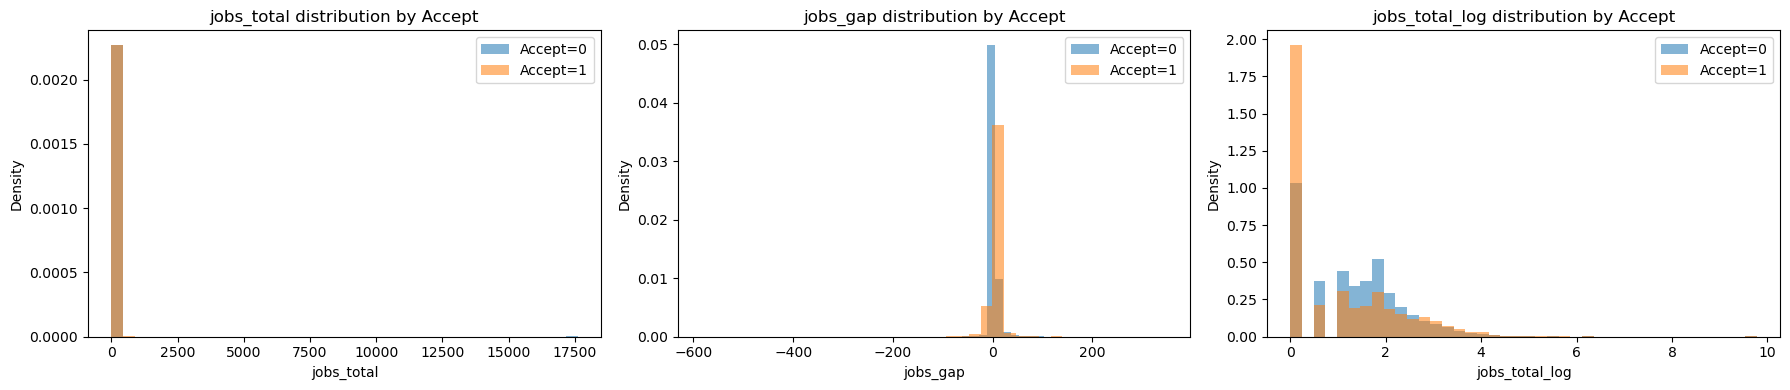

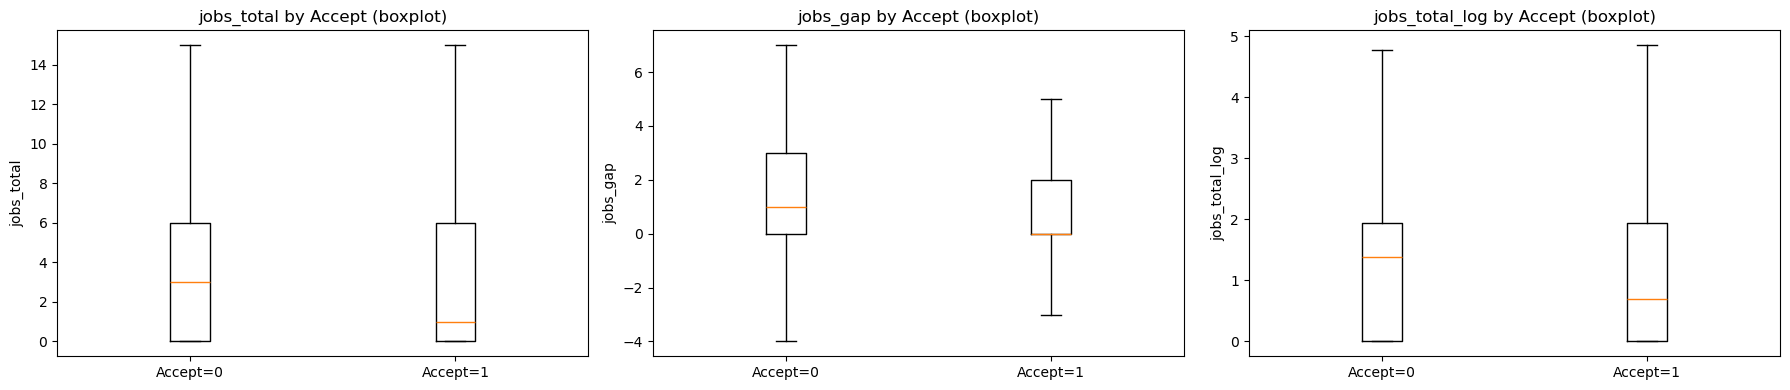

In [4]:
import sys
import importlib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure src/ is importable when notebook runs from notebooks/team-notebooks
project_root = Path.cwd().resolve().parents[1]
src_path = project_root / 'src'
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

# Force reload so notebook sees latest edits in src/preprocessing/one_step.py
import preprocessing.one_step as one_step
importlib.reload(one_step)
OneStepOptions = one_step.OneStepOptions
preprocess_one_step = one_step.preprocess_one_step

# Load training data
df_raw = pd.read_csv(project_root / 'data' / 'train.csv')

# Use tree-focused preprocessing so engineered jobs_* columns are created
opts = OneStepOptions(
    noemp_option='trees',
    newexist_option='A',
    createjob_option='trees',
    retainedjob_option='trees',
    approvaldate_option='C',
    approvalfy_option='B',
    franchise_option='binary',
    urbanrural_option='onehot',
    revlinecr_option='C',
    lowdoc_option='C',
    disbursementgross_option='trees',
    balancegross_option='trees',
    local_state='IL',
)

df_proc = preprocess_one_step(df_raw, options=opts, is_tree_model=True)
print('jobs columns present:', [c for c in ['jobs_total', 'jobs_gap', 'jobs_total_log'] if c in df_proc.columns])

# Safety net: if jobs_total_log is still missing, create it on-the-fly for analysis
if 'jobs_total_log' not in df_proc.columns and 'jobs_total' in df_proc.columns:
    df_proc['jobs_total_log'] = np.log1p(pd.to_numeric(df_proc['jobs_total'], errors='coerce').clip(lower=0))
    print("[INFO] Built jobs_total_log from jobs_total inside notebook cell.")

analysis_cols = ['jobs_total', 'jobs_gap', 'jobs_total_log', 'Accept']
missing = [c for c in analysis_cols if c not in df_proc.columns]
if missing:
    raise ValueError(f'Missing expected columns after reload/fallback: {missing}')

df_plot = df_proc[analysis_cols].copy().dropna()
df_plot['Accept'] = df_plot['Accept'].astype(int)

print('Rows used for analysis:', len(df_plot))
print('\nSummary by Accept:')
print(df_plot.groupby('Accept')[['jobs_total', 'jobs_gap', 'jobs_total_log']].describe().round(3))

# Correlation with binary target as a quick signal-strength view
corr = df_plot[['jobs_total', 'jobs_gap', 'jobs_total_log', 'Accept']].corr(numeric_only=True)['Accept'].drop('Accept')
print('\nPearson correlation with Accept:')
print(corr.sort_values(ascending=False).round(4))

# Plot 1: class-wise distributions
features = ['jobs_total', 'jobs_gap', 'jobs_total_log']
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(features):
    a0 = df_plot.loc[df_plot['Accept'] == 0, col]
    a1 = df_plot.loc[df_plot['Accept'] == 1, col]
    axes[i].hist(a0, bins=40, alpha=0.55, label='Accept=0', density=True)
    axes[i].hist(a1, bins=40, alpha=0.55, label='Accept=1', density=True)
    axes[i].set_title(f'{col} distribution by Accept')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()
plt.tight_layout()
plt.show()

# Plot 2: boxplots for separation/outlier view
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, col in enumerate(features):
    data_0 = df_plot.loc[df_plot['Accept'] == 0, col].values
    data_1 = df_plot.loc[df_plot['Accept'] == 1, col].values
    axes[i].boxplot([data_0, data_1], tick_labels=['Accept=0', 'Accept=1'], showfliers=False)
    axes[i].set_title(f'{col} by Accept (boxplot)')
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.show()

Data quality summary (raw input columns):
                rows  missing_n  missing_pct   zero_n  zero_pct_of_valid  \
CreateJob    20768.0        0.0          0.0  13919.0              67.02   
RetainedJob  20768.0        0.0          0.0  10484.0              50.48   

             positive_n  positive_pct_of_valid  
CreateJob        6849.0                  32.98  
RetainedJob     10284.0                  49.52  


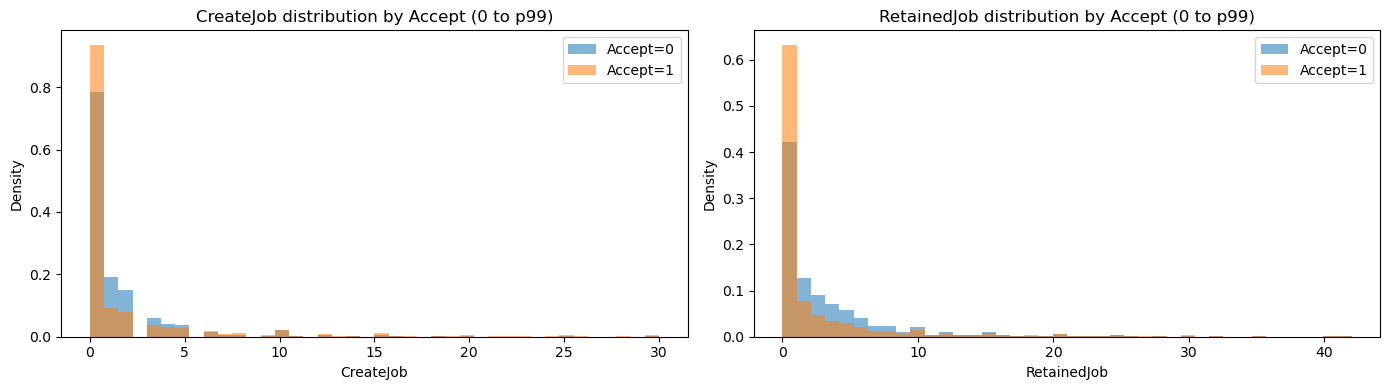

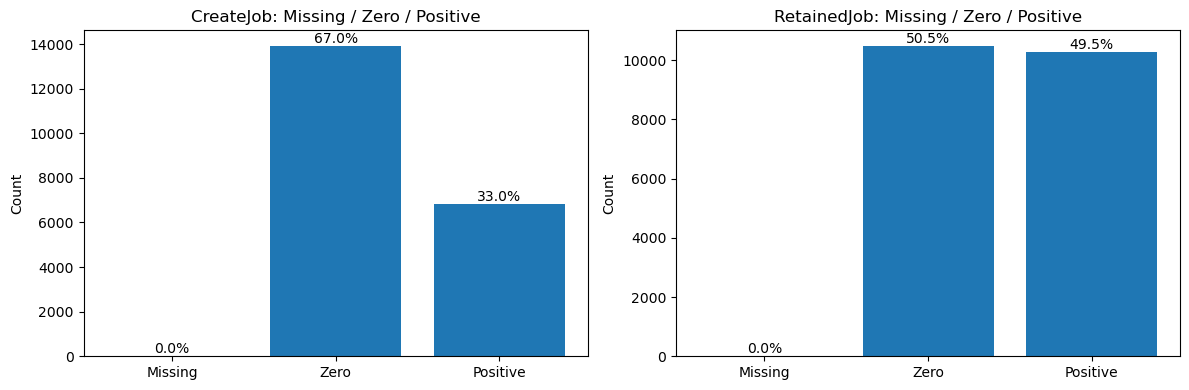

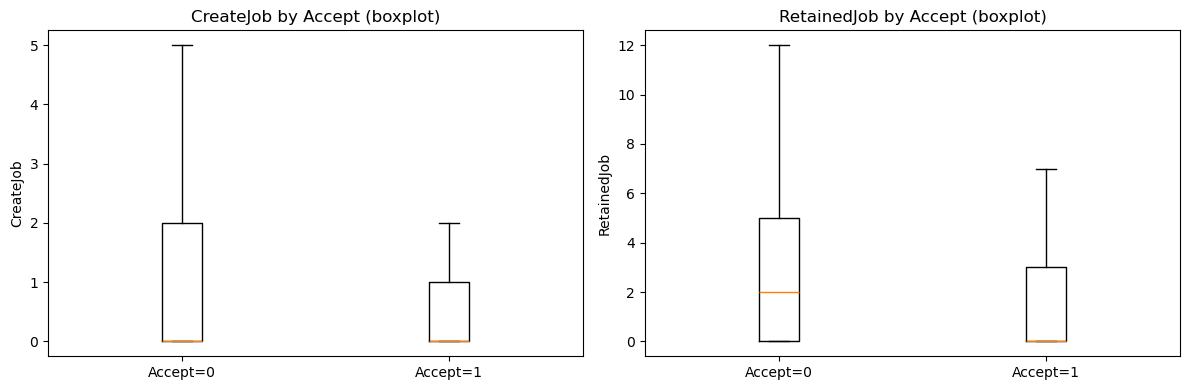

In [5]:
# Cell 2: Data quality and distribution analysis for CreateJob and RetainedJob
jobs_cols = ['CreateJob', 'RetainedJob', 'Accept']
missing_cols = [c for c in jobs_cols if c not in df_raw.columns]
if missing_cols:
    raise ValueError(f'Missing expected raw columns: {missing_cols}')

df_jobs_raw = df_raw[jobs_cols].copy()
df_jobs_raw['CreateJob'] = pd.to_numeric(df_jobs_raw['CreateJob'], errors='coerce')
df_jobs_raw['RetainedJob'] = pd.to_numeric(df_jobs_raw['RetainedJob'], errors='coerce')
df_jobs_raw['Accept'] = pd.to_numeric(df_jobs_raw['Accept'], errors='coerce').astype('Int64')

def quality_table(series: pd.Series) -> dict:
    valid = series.dropna()
    return {
        'rows': len(series),
        'missing_n': int(series.isna().sum()),
        'missing_pct': float(series.isna().mean() * 100),
        'zero_n': int((valid == 0).sum()),
        'zero_pct_of_valid': float(((valid == 0).mean() * 100) if len(valid) else np.nan),
        'positive_n': int((valid > 0).sum()),
        'positive_pct_of_valid': float(((valid > 0).mean() * 100) if len(valid) else np.nan),
    }

quality = pd.DataFrame({
    'CreateJob': quality_table(df_jobs_raw['CreateJob']),
    'RetainedJob': quality_table(df_jobs_raw['RetainedJob']),
}).T.round(2)

print('Data quality summary (raw input columns):')
print(quality)

# Distribution plots with robust x-limits (trim extreme outliers for readability)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, col in enumerate(['CreateJob', 'RetainedJob']):
    s = df_jobs_raw[col].dropna()
    x_max = float(np.nanpercentile(s, 99)) if len(s) else 1.0
    a0 = df_jobs_raw.loc[df_jobs_raw['Accept'] == 0, col].dropna()
    a1 = df_jobs_raw.loc[df_jobs_raw['Accept'] == 1, col].dropna()
    axes[i].hist(a0, bins=40, alpha=0.55, label='Accept=0', density=True, range=(0, x_max))
    axes[i].hist(a1, bins=40, alpha=0.55, label='Accept=1', density=True, range=(0, x_max))
    axes[i].set_title(f'{col} distribution by Accept (0 to p99)')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Density')
    axes[i].legend()
plt.tight_layout()
plt.show()

# Category mix to test the 'not requested' hypothesis: Missing vs Zero vs Positive
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(['CreateJob', 'RetainedJob']):
    s = df_jobs_raw[col]
    cats = pd.Series(np.where(s.isna(), 'Missing', np.where(s == 0, 'Zero', 'Positive')))
    counts = cats.value_counts().reindex(['Missing', 'Zero', 'Positive']).fillna(0)
    axes[i].bar(counts.index, counts.values)
    axes[i].set_title(f'{col}: Missing / Zero / Positive')
    axes[i].set_ylabel('Count')
    for x, y in enumerate(counts.values):
        pct = 100.0 * y / len(s)
        axes[i].text(x, y, f'{pct:.1f}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()

# Boxplots by target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, col in enumerate(['CreateJob', 'RetainedJob']):
    d0 = df_jobs_raw.loc[df_jobs_raw['Accept'] == 0, col].dropna()
    d1 = df_jobs_raw.loc[df_jobs_raw['Accept'] == 1, col].dropna()
    axes[i].boxplot([d0, d1], tick_labels=['Accept=0', 'Accept=1'], showfliers=False)
    axes[i].set_title(f'{col} by Accept (boxplot)')
    axes[i].set_ylabel(col)
plt.tight_layout()
plt.show()


CreateJob - Accept rate by zero vs positive:
   group  n_rows  accept_rate
    zero   13919     0.799914
positive    6849     0.713243
Absolute lift (positive - zero): -8.67 pp
Relative lift: -10.84%

RetainedJob - Accept rate by zero vs positive:
   group  n_rows  accept_rate
    zero   10484     0.874475
positive   10284     0.666180
Absolute lift (positive - zero): -20.83 pp
Relative lift: -23.82%


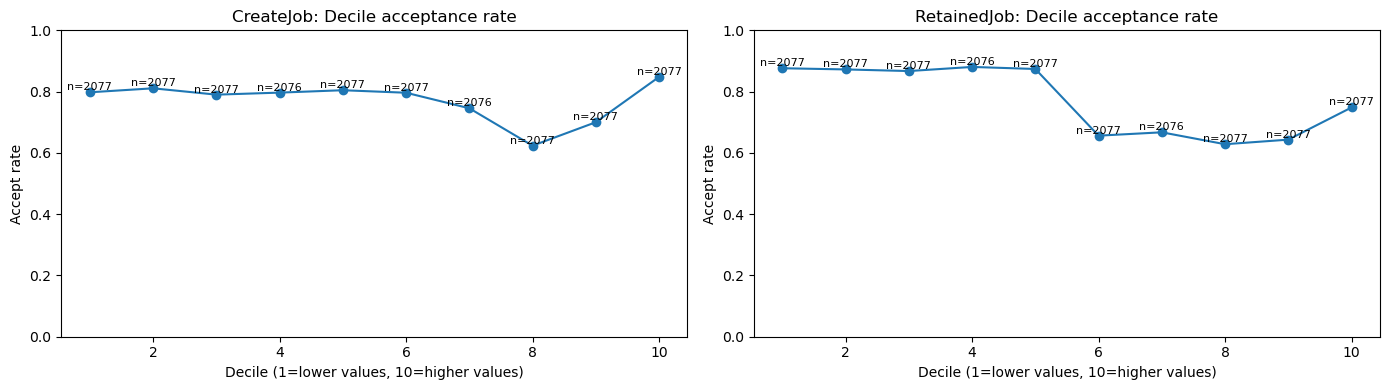

In [6]:
# Cell 3: Quantify predictive lift for CreateJob/RetainedJob
df_lift = df_jobs_raw[['CreateJob', 'RetainedJob', 'Accept']].copy().dropna()
df_lift['Accept'] = df_lift['Accept'].astype(int)

def acceptance_rate(series, target):
    tmp = pd.DataFrame({'x': series, 'y': target}).dropna()
    return float(tmp['y'].mean()) if len(tmp) else np.nan

def zero_vs_positive_lift(df_in: pd.DataFrame, feature: str) -> pd.DataFrame:
    s = pd.to_numeric(df_in[feature], errors='coerce')
    y = pd.to_numeric(df_in['Accept'], errors='coerce')
    mask_zero = s == 0
    mask_pos = s > 0

    rate_zero = acceptance_rate(s[mask_zero], y[mask_zero])
    rate_pos = acceptance_rate(s[mask_pos], y[mask_pos])
    abs_lift_pp = (rate_pos - rate_zero) * 100.0
    rel_lift_pct = ((rate_pos / rate_zero) - 1.0) * 100.0 if rate_zero > 0 else np.nan

    return pd.DataFrame({
        'group': ['zero', 'positive'],
        'n_rows': [int(mask_zero.sum()), int(mask_pos.sum())],
        'accept_rate': [rate_zero, rate_pos],
    }), abs_lift_pp, rel_lift_pct

for feat in ['CreateJob', 'RetainedJob']:
    summary_df, abs_lift_pp, rel_lift_pct = zero_vs_positive_lift(df_lift, feat)
    print(f'\n{feat} - Accept rate by zero vs positive:')
    print(summary_df.to_string(index=False))
    print(f'Absolute lift (positive - zero): {abs_lift_pp:.2f} pp')
    print(f'Relative lift: {rel_lift_pct:.2f}%')

# Decile-binned acceptance-rate curves
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for i, feat in enumerate(['CreateJob', 'RetainedJob']):
    x = pd.to_numeric(df_lift[feat], errors='coerce')
    y = pd.to_numeric(df_lift['Accept'], errors='coerce')

    # qcut can fail on heavy ties; rank() creates a stable monotonic order for bins
    valid = pd.DataFrame({'x': x, 'y': y}).dropna().copy()
    valid['ranked'] = valid['x'].rank(method='first')
    valid['bin'] = pd.qcut(valid['ranked'], q=10, labels=False) + 1

    curve = valid.groupby('bin').agg(
        mean_feature=('x', 'mean'),
        accept_rate=('y', 'mean'),
        n=('y', 'size')
    ).reset_index()

    axes[i].plot(curve['bin'], curve['accept_rate'], marker='o')
    axes[i].set_title(f'{feat}: Decile acceptance rate')
    axes[i].set_xlabel('Decile (1=lower values, 10=higher values)')
    axes[i].set_ylabel('Accept rate')
    axes[i].set_ylim(0, 1)
    for _, row in curve.iterrows():
        axes[i].text(row['bin'], row['accept_rate'], f"n={int(row['n'])}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Acceptance-rate matrix by buckets (rows=CreateJob, cols=RetainedJob):
RetainedJob_bucket      0    1-2    3-5   6-10    11+
CreateJob_bucket                                     
0                   0.865  0.670  0.658  0.695  0.777
1-2                 0.833  0.624  0.581  0.591  0.735
3-5                 0.908  0.629  0.628  0.639  0.761
6-10                0.943  0.763  0.743  0.716  0.726
11+                 0.971  0.679  0.893  0.778  0.784

Count matrix by buckets:
RetainedJob_bucket     0   1-2   3-5  6-10  11+
CreateJob_bucket                               
0                   8878  2217  1379   753  692
1-2                  263  1279  1016   494  196
3-5                  359   318   446   274  243
6-10                 401   139    74   176  179
11+                  583    81    28    27  273


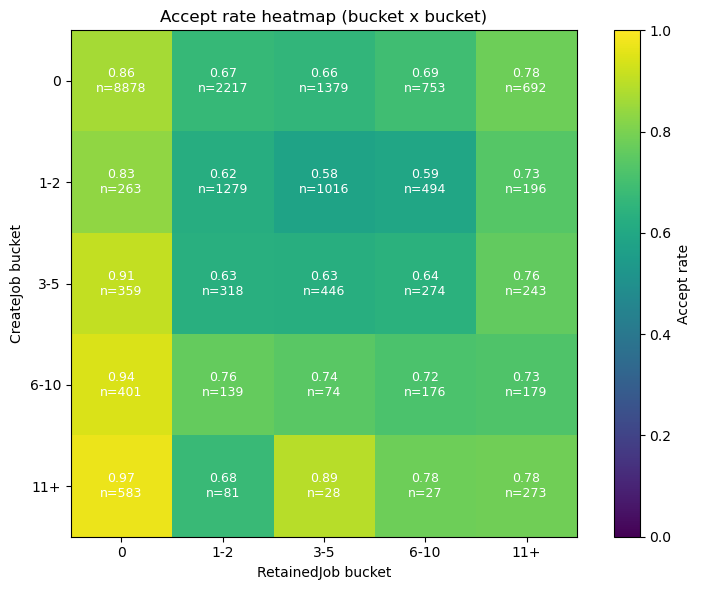

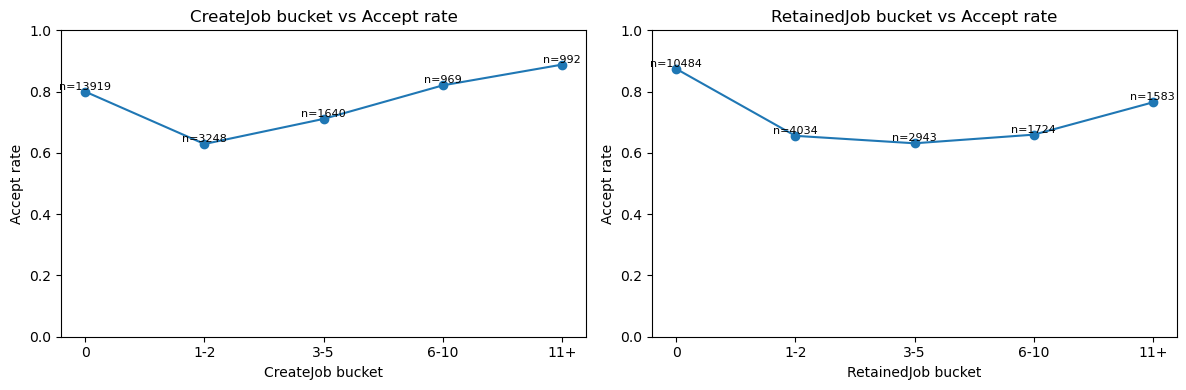

In [7]:
# Cell 4: Bucket analysis (CreateJob x RetainedJob)
bucket_df = df_jobs_raw[['CreateJob', 'RetainedJob', 'Accept']].copy()
bucket_df['CreateJob'] = pd.to_numeric(bucket_df['CreateJob'], errors='coerce').fillna(0).clip(lower=0)
bucket_df['RetainedJob'] = pd.to_numeric(bucket_df['RetainedJob'], errors='coerce').fillna(0).clip(lower=0)
bucket_df['Accept'] = pd.to_numeric(bucket_df['Accept'], errors='coerce').fillna(0).astype(int)

# Hand-crafted business buckets: easy to interpret and tree-friendly
bin_edges = [-0.1, 0, 2, 5, 10, 1e9]
bin_labels = ['0', '1-2', '3-5', '6-10', '11+']

bucket_df['CreateJob_bucket'] = pd.cut(bucket_df['CreateJob'], bins=bin_edges, labels=bin_labels)
bucket_df['RetainedJob_bucket'] = pd.cut(bucket_df['RetainedJob'], bins=bin_edges, labels=bin_labels)

# 2D acceptance-rate matrix
rate_matrix = pd.pivot_table(
    bucket_df,
    index='CreateJob_bucket',
    columns='RetainedJob_bucket',
    values='Accept',
    aggfunc='mean',
    observed=False
)

count_matrix = pd.pivot_table(
    bucket_df,
    index='CreateJob_bucket',
    columns='RetainedJob_bucket',
    values='Accept',
    aggfunc='size',
    observed=False
).fillna(0).astype(int)

print('Acceptance-rate matrix by buckets (rows=CreateJob, cols=RetainedJob):')
print(rate_matrix.round(3))
print('\nCount matrix by buckets:')
print(count_matrix)

# Heatmap visualization
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(rate_matrix.values, cmap='viridis', vmin=0, vmax=1)

ax.set_xticks(range(len(rate_matrix.columns)))
ax.set_yticks(range(len(rate_matrix.index)))
ax.set_xticklabels(rate_matrix.columns)
ax.set_yticklabels(rate_matrix.index)
ax.set_xlabel('RetainedJob bucket')
ax.set_ylabel('CreateJob bucket')
ax.set_title('Accept rate heatmap (bucket x bucket)')

# annotate each cell with rate and n
for r in range(rate_matrix.shape[0]):
    for c in range(rate_matrix.shape[1]):
        rate = rate_matrix.iloc[r, c]
        n = count_matrix.iloc[r, c]
        txt = f'{rate:.2f}\nn={n}' if pd.notna(rate) else f'NA\nn={n}'
        ax.text(c, r, txt, ha='center', va='center', color='white', fontsize=9)

fig.colorbar(im, ax=ax, label='Accept rate')
plt.tight_layout()
plt.show()

# 1D bucket curves for each feature
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, feat in enumerate(['CreateJob', 'RetainedJob']):
    bcol = f'{feat}_bucket'
    summary = bucket_df.groupby(bcol, observed=False).agg(
        accept_rate=('Accept', 'mean'),
        n=('Accept', 'size')
    ).reindex(bin_labels)

    axes[i].plot(bin_labels, summary['accept_rate'], marker='o')
    axes[i].set_ylim(0, 1)
    axes[i].set_title(f'{feat} bucket vs Accept rate')
    axes[i].set_xlabel(f'{feat} bucket')
    axes[i].set_ylabel('Accept rate')
    for j, (label, row) in enumerate(summary.iterrows()):
        axes[i].text(j, row['accept_rate'], f"n={int(row['n'])}", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

Zero vs positive acceptance within franchise strata:
      segment     feature  n_total  n_zero  n_positive  accept_rate_zero  accept_rate_positive  lift_positive_minus_zero_pp
Non-franchise   CreateJob    19413   12955        6458            0.7963                0.7086                      -8.7716
    Franchise   CreateJob     1355     964         391            0.8485                0.7903                      -5.8266
Non-franchise RetainedJob    19413    9503        9910            0.8758                0.6629                     -21.2963
    Franchise RetainedJob     1355     981         374            0.8614                0.7540                     -10.7355


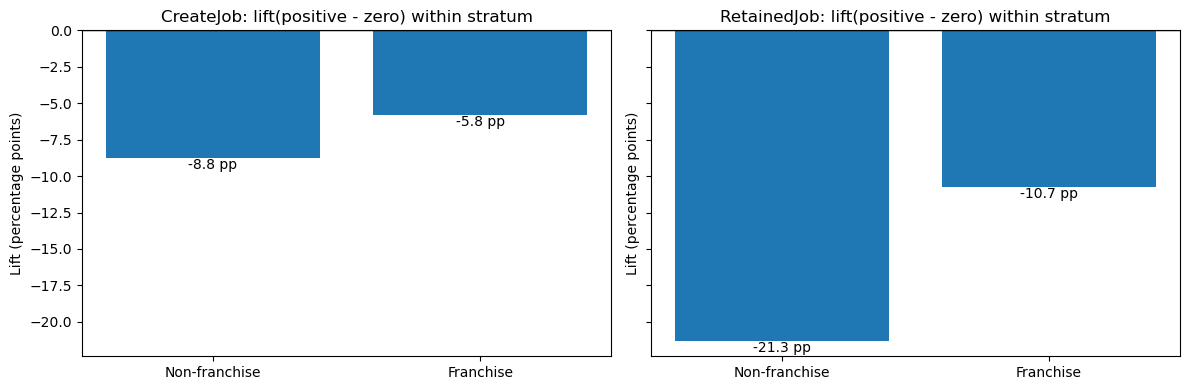


Baseline acceptance by franchise segment:
      segment  accept_rate     n
Non-franchise       0.7671 19413
    Franchise       0.8317  1355


In [8]:
# Cell 5: Does franchise status absorb CreateJob/RetainedJob signal?
cols_needed = ['CreateJob', 'RetainedJob', 'Accept']
franchise_col = 'IsFranchise' if 'IsFranchise' in df_proc.columns else None
if franchise_col is None:
    raise ValueError("'IsFranchise' not found in df_proc. Check franchise preprocessing option.")

df_hyp = df_proc.copy()
for c in cols_needed:
    df_hyp[c] = pd.to_numeric(df_hyp[c], errors='coerce')
df_hyp[franchise_col] = pd.to_numeric(df_hyp[franchise_col], errors='coerce').fillna(0).astype(int)
df_hyp = df_hyp[cols_needed + [franchise_col]].dropna()
df_hyp['Accept'] = df_hyp['Accept'].astype(int)

def zero_pos_summary(df_in: pd.DataFrame, feature: str, group_col: str) -> pd.DataFrame:
    out = []
    for grp_val, grp_name in [(0, 'Non-franchise'), (1, 'Franchise')]:
        d = df_in[df_in[group_col] == grp_val].copy()
        if len(d) == 0:
            continue

        m0 = d[feature] == 0
        mp = d[feature] > 0
        rate0 = d.loc[m0, 'Accept'].mean() if m0.any() else np.nan
        ratep = d.loc[mp, 'Accept'].mean() if mp.any() else np.nan

        out.append({
            'segment': grp_name,
            'feature': feature,
            'n_total': int(len(d)),
            'n_zero': int(m0.sum()),
            'n_positive': int(mp.sum()),
            'accept_rate_zero': float(rate0) if pd.notna(rate0) else np.nan,
            'accept_rate_positive': float(ratep) if pd.notna(ratep) else np.nan,
            'lift_positive_minus_zero_pp': float((ratep - rate0) * 100.0) if pd.notna(rate0) and pd.notna(ratep) else np.nan,
        })
    return pd.DataFrame(out)

summary_create = zero_pos_summary(df_hyp, 'CreateJob', franchise_col)
summary_ret = zero_pos_summary(df_hyp, 'RetainedJob', franchise_col)
summary_all = pd.concat([summary_create, summary_ret], ignore_index=True)

print('Zero vs positive acceptance within franchise strata:')
print(summary_all.round(4).to_string(index=False))

# Plot the within-strata lift for quick visual check
plot_df = summary_all.copy()
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for i, feat in enumerate(['CreateJob', 'RetainedJob']):
    d = plot_df[plot_df['feature'] == feat]
    axes[i].bar(d['segment'], d['lift_positive_minus_zero_pp'])
    axes[i].axhline(0, color='black', linewidth=1)
    axes[i].set_title(f'{feat}: lift(positive - zero) within stratum')
    axes[i].set_ylabel('Lift (percentage points)')
    for x, y in enumerate(d['lift_positive_minus_zero_pp'].values):
        axes[i].text(x, y, f'{y:.1f} pp', ha='center', va='bottom' if y >= 0 else 'top')
plt.tight_layout()
plt.show()

# Extra check: Accept rate by franchise only (baseline effect)
base = df_hyp.groupby(franchise_col)['Accept'].agg(['mean', 'size']).reset_index()
base['segment'] = base[franchise_col].map({0: 'Non-franchise', 1: 'Franchise'}).fillna('Unknown')
print('\nBaseline acceptance by franchise segment:')
print(base[['segment', 'mean', 'size']].rename(columns={'mean': 'accept_rate', 'size': 'n'}).round(4).to_string(index=False))

Rows used: 20768

Basic summary:
           NoEmp  CreateJob  RetainedJob  retained_to_emp_ratio  \
count  20768.000  20768.000    20768.000              20556.000   
mean      10.784      6.878        8.085                  2.175   
std       76.659    202.723      202.633                 96.670   
min        0.000      0.000        0.000                  0.000   
25%        2.000      0.000        0.000                  0.000   
50%        4.000      0.000        0.000                  0.000   
75%       10.000      1.000        3.000                  1.000   
max     7389.000   8800.000     8800.000               8800.000   

       retained_minus_emp  
count           20768.000  
mean               -2.699  
std               216.331  
min             -7389.000  
25%                -6.000  
50%                -1.000  
75%                 0.000  
max              8799.000  

Share where RetainedJob > NoEmp: 8.37%

NoEmp vs RetainedJob bucket count matrix:
Retained_bucket     0   1-2 

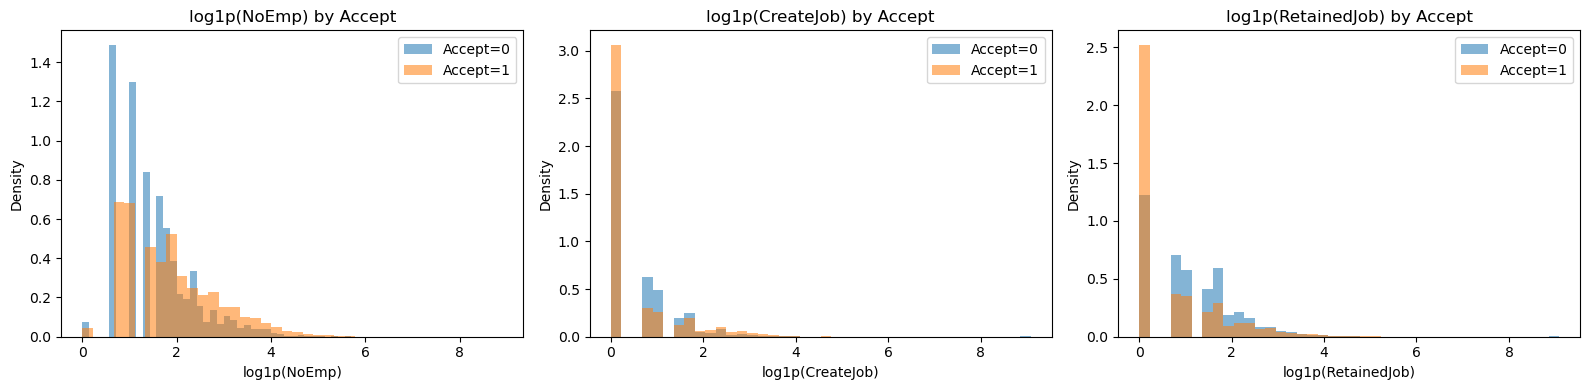

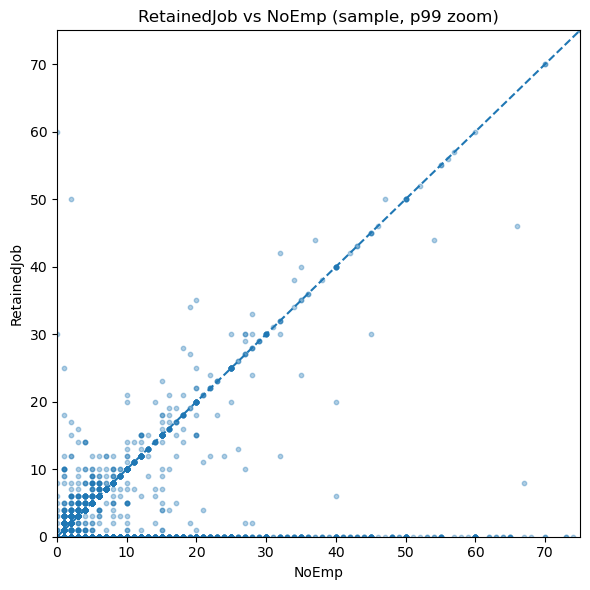


Acceptance by RetainedJob/NoEmp ratio bucket:
              accept_rate      n
ratio_bucket                    
0                  0.8755  10347
(0,0.5]            0.7909    330
(0.5,1.0]          0.6764   8215
(1.0,2.0]          0.5780   1225
>2.0               0.6196    439


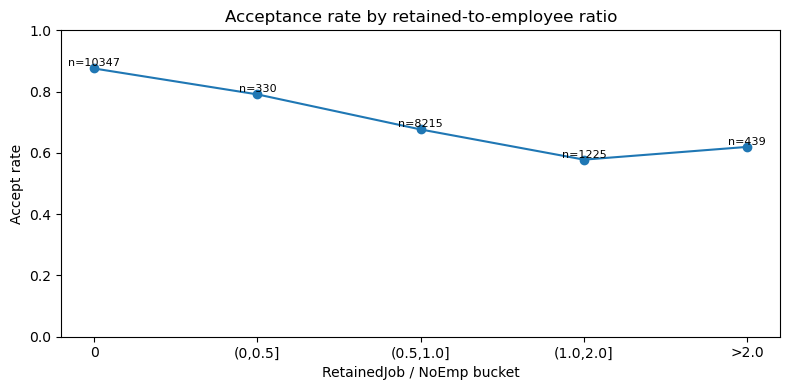

In [9]:
# Cell 6: CreateJob/RetainedJob vs NoEmp (employee count)
emp_cols = ['NoEmp', 'CreateJob', 'RetainedJob', 'Accept']
emp_missing = [c for c in emp_cols if c not in df_raw.columns]
if emp_missing:
    raise ValueError(f'Missing expected columns in df_raw: {emp_missing}')

df_emp = df_raw[emp_cols].copy()
for c in ['NoEmp', 'CreateJob', 'RetainedJob', 'Accept']:
    df_emp[c] = pd.to_numeric(df_emp[c], errors='coerce')

# Keep a clean analysis frame
df_emp = df_emp.dropna(subset=['NoEmp', 'CreateJob', 'RetainedJob', 'Accept']).copy()
df_emp['NoEmp'] = df_emp['NoEmp'].clip(lower=0)
df_emp['CreateJob'] = df_emp['CreateJob'].clip(lower=0)
df_emp['RetainedJob'] = df_emp['RetainedJob'].clip(lower=0)
df_emp['Accept'] = df_emp['Accept'].astype(int)

# Consistency diagnostics
den = df_emp['NoEmp'].replace(0, np.nan)
df_emp['retained_to_emp_ratio'] = df_emp['RetainedJob'] / den
df_emp['retained_minus_emp'] = df_emp['RetainedJob'] - df_emp['NoEmp']
df_emp['retained_exceeds_emp'] = (df_emp['RetainedJob'] > df_emp['NoEmp']).astype(int)

print('Rows used:', len(df_emp))
print('\nBasic summary:')
print(df_emp[['NoEmp', 'CreateJob', 'RetainedJob', 'retained_to_emp_ratio', 'retained_minus_emp']].describe().round(3))

exceeds_rate = 100.0 * df_emp['retained_exceeds_emp'].mean()
print(f"\nShare where RetainedJob > NoEmp: {exceeds_rate:.2f}%")

# Match buckets to inspect relationship quality
bucket_edges = [-0.1, 0, 2, 5, 10, 50, 1e9]
bucket_labels = ['0', '1-2', '3-5', '6-10', '11-50', '51+']
df_emp['NoEmp_bucket'] = pd.cut(df_emp['NoEmp'], bins=bucket_edges, labels=bucket_labels)
df_emp['Retained_bucket'] = pd.cut(df_emp['RetainedJob'], bins=bucket_edges, labels=bucket_labels)

match_matrix = pd.pivot_table(
    df_emp.assign(match=(df_emp['NoEmp_bucket'] == df_emp['Retained_bucket']).astype(int)),
    index='NoEmp_bucket',
    columns='Retained_bucket',
    values='match',
    aggfunc='size',
    observed=False
).fillna(0).astype(int)

print('\nNoEmp vs RetainedJob bucket count matrix:')
print(match_matrix)

# Plot A: distributions on log scale for readability
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for i, col in enumerate(['NoEmp', 'CreateJob', 'RetainedJob']):
    vals0 = np.log1p(df_emp.loc[df_emp['Accept'] == 0, col])
    vals1 = np.log1p(df_emp.loc[df_emp['Accept'] == 1, col])
    axes[i].hist(vals0, bins=40, alpha=0.55, label='Accept=0', density=True)
    axes[i].hist(vals1, bins=40, alpha=0.55, label='Accept=1', density=True)
    axes[i].set_title(f'log1p({col}) by Accept')
    axes[i].set_xlabel(f'log1p({col})')
    axes[i].set_ylabel('Density')
    axes[i].legend()
plt.tight_layout()
plt.show()

# Plot B: RetainedJob vs NoEmp scatter sample + y=x reference
plot_n = min(4000, len(df_emp))
sample = df_emp.sample(plot_n, random_state=42)
xy_max = np.nanpercentile(np.r_[sample['NoEmp'].values, sample['RetainedJob'].values], 99)
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(sample['NoEmp'], sample['RetainedJob'], s=10, alpha=0.35)
ax.plot([0, xy_max], [0, xy_max], linestyle='--')
ax.set_xlim(0, xy_max)
ax.set_ylim(0, xy_max)
ax.set_xlabel('NoEmp')
ax.set_ylabel('RetainedJob')
ax.set_title('RetainedJob vs NoEmp (sample, p99 zoom)')
plt.tight_layout()
plt.show()

# Plot C: acceptance by retained-to-employee ratio buckets
ratio_bins = [-np.inf, 0, 0.5, 1.0, 2.0, np.inf]
ratio_labels = ['0', '(0,0.5]', '(0.5,1.0]', '(1.0,2.0]', '>2.0']
df_ratio = df_emp.copy()
df_ratio['ratio_bucket'] = pd.cut(df_ratio['retained_to_emp_ratio'], bins=ratio_bins, labels=ratio_labels)
ratio_summary = df_ratio.groupby('ratio_bucket', observed=False).agg(
    accept_rate=('Accept', 'mean'),
    n=('Accept', 'size')
).reindex(ratio_labels)

print('\nAcceptance by RetainedJob/NoEmp ratio bucket:')
print(ratio_summary.round(4))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ratio_summary.index.astype(str), ratio_summary['accept_rate'], marker='o')
ax.set_ylim(0, 1)
ax.set_xlabel('RetainedJob / NoEmp bucket')
ax.set_ylabel('Accept rate')
ax.set_title('Acceptance rate by retained-to-employee ratio')
for i, (_, row) in enumerate(ratio_summary.iterrows()):
    ax.text(i, row['accept_rate'], f"n={int(row['n'])}", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()

Rows with NoEmp > 0: 20556
Share where RetainedJob > NoEmp (NoEmp>0 only): 8.09%

Acceptance by RetainedJob/NoEmp ratio bucket (NoEmp>0):
              accept_rate      n
ratio_bucket                    
(0,0.5]            0.8729  10677
(0.5,1.0]          0.6764   8215
(1.0,2.0]          0.5780   1225
>2.0               0.6196    439


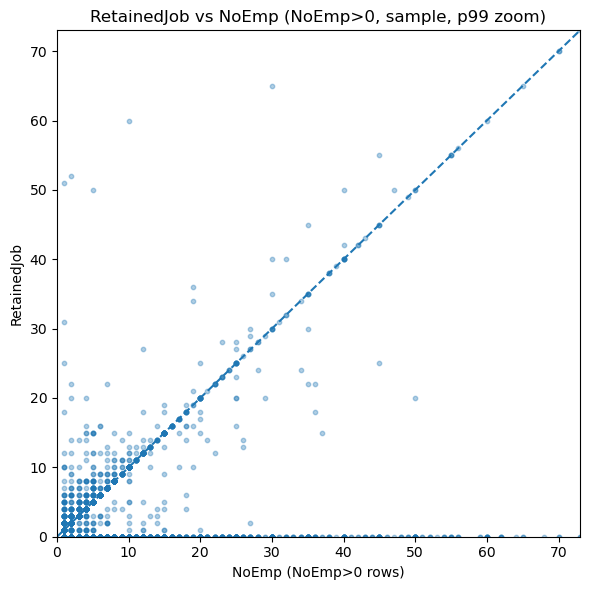

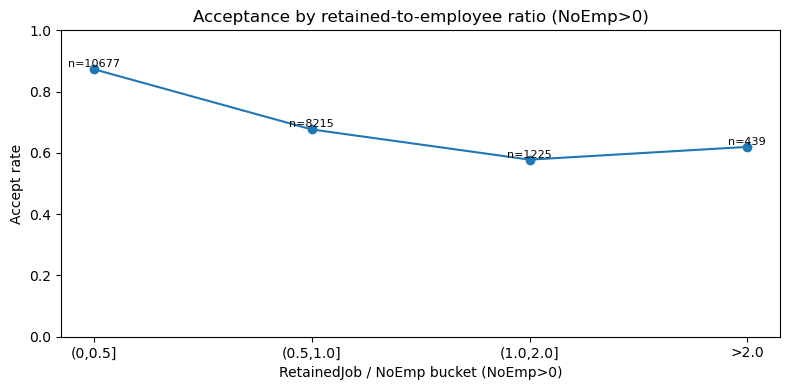

In [10]:
# Cell 7: Same ratio analysis but only for NoEmp > 0
df_emp_pos = df_emp[df_emp['NoEmp'] > 0].copy()

df_emp_pos['retained_to_emp_ratio'] = df_emp_pos['RetainedJob'] / df_emp_pos['NoEmp']
df_emp_pos['retained_exceeds_emp'] = (df_emp_pos['RetainedJob'] > df_emp_pos['NoEmp']).astype(int)

print('Rows with NoEmp > 0:', len(df_emp_pos))
print('Share where RetainedJob > NoEmp (NoEmp>0 only): '
      f"{100.0 * df_emp_pos['retained_exceeds_emp'].mean():.2f}%")

# Ratio bucket view (no zero-employee denominator issue)
ratio_bins_pos = [0, 0.5, 1.0, 2.0, np.inf]
ratio_labels_pos = ['(0,0.5]', '(0.5,1.0]', '(1.0,2.0]', '>2.0']
df_emp_pos['ratio_bucket'] = pd.cut(
    df_emp_pos['retained_to_emp_ratio'],
    bins=ratio_bins_pos,
    labels=ratio_labels_pos,
    include_lowest=True,
    right=True,
)

ratio_summary_pos = df_emp_pos.groupby('ratio_bucket', observed=False).agg(
    accept_rate=('Accept', 'mean'),
    n=('Accept', 'size')
).reindex(ratio_labels_pos)

print('\nAcceptance by RetainedJob/NoEmp ratio bucket (NoEmp>0):')
print(ratio_summary_pos.round(4))

# Scatter + y=x for non-zero employee firms
plot_n = min(4000, len(df_emp_pos))
sample_pos = df_emp_pos.sample(plot_n, random_state=42)
xy_max = np.nanpercentile(np.r_[sample_pos['NoEmp'].values, sample_pos['RetainedJob'].values], 99)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(sample_pos['NoEmp'], sample_pos['RetainedJob'], s=10, alpha=0.35)
ax.plot([0, xy_max], [0, xy_max], linestyle='--')
ax.set_xlim(0, xy_max)
ax.set_ylim(0, xy_max)
ax.set_xlabel('NoEmp (NoEmp>0 rows)')
ax.set_ylabel('RetainedJob')
ax.set_title('RetainedJob vs NoEmp (NoEmp>0, sample, p99 zoom)')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(ratio_summary_pos.index.astype(str), ratio_summary_pos['accept_rate'], marker='o')
ax.set_ylim(0, 1)
ax.set_xlabel('RetainedJob / NoEmp bucket (NoEmp>0)')
ax.set_ylabel('Accept rate')
ax.set_title('Acceptance by retained-to-employee ratio (NoEmp>0)')
for i, (_, row) in enumerate(ratio_summary_pos.iterrows()):
    ax.text(i, row['accept_rate'], f"n={int(row['n'])}", ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.show()